<a href="https://colab.research.google.com/github/HusnulAmira/ADW/blob/main/TUGAS_2_PRAKTIKUM_ADW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [105]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1059)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 29.5
beta0 = 69
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


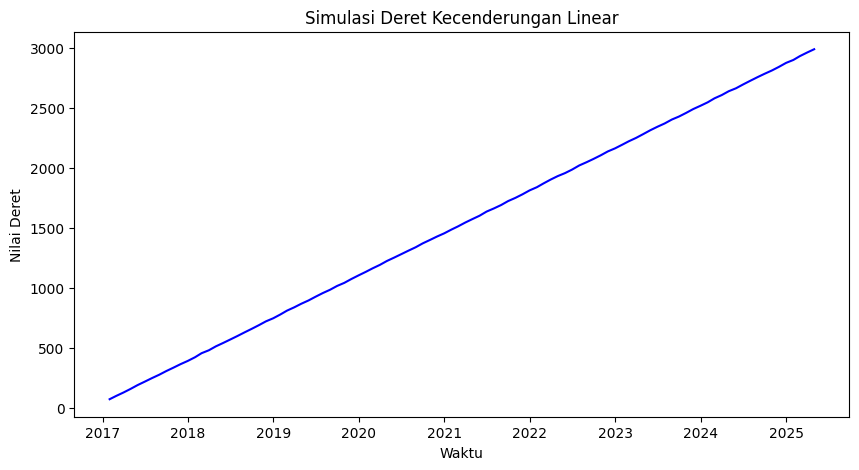

In [106]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

berdasarkan grafik simulasi deret kecenderungan linear diatas, terlihat bahwa terdapat korelasi positif antar waktu pengamatan dengan nilai deret. hal tersebut dapat dilihat dari pola data yg meningkat secara konsisten dari tahun ke tahun. Semakin bertambah periode waktu pengamatan yang di lakukan, semakin besar nilai deret yang dihasilkan. hubungan yg membentuk pola garis lurus ini menunjukkan bahwa antar pengamatan memiliki korelasi linear positif yang kuat. maksudnya, perubahan pada waktu diikuti oleh perubahan nilai deret secara searah. jadi, dapat disimpulkan bahwa terdapat kecenderungan tren meningkat dan adanya hubungan yang sistematis antar pengamatan

Cek apakah ada korelasi antar pengamatan?

In [107]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


berdasarkan nilai korelasi yg didapatkan yaitu 1,000 yang artinya mendekati +1 menunjukkan hubungan linear positif yg sempurna antar waktu pengamatan dan nilai deretnya

In [108]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.290e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          7.02e-265
Time:                        13:04:19   Log-Likelihood:                -198.55
No. Observations:                 100   AIC:                             401.1
Df Residuals:                      98   BIC:                             406.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           68.6225      0.353    194.202   

Hasil analisis regresi linear menunjukkan bahwa terdapat hubungan positif yang sangat kuat antara waktu pengamatan dan nilai deret. model regresi yang di dapatkan Y = 68,62 + 59,50X yang menunjukkan bahwa setiap peningkatan satu periode waktu menyebabkan nilai deret meningkat sebesar 59,50 satuan.Nilai R-squared sebesar 1,000 menunjukkan bahwa model mampu menjelaskan seluruh variasi data. Selain itu, hasil uji t dan uji F menunjukkan bahwa pengaruh waktu terhadap nilai deret signifikan secara statistik. Dengan demikian, data memiliki kecenderungan linear meningkat dan antar pengamatan memiliki hubungan yang sangat kuat.

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Apakah model regresi yang dipaskan sudah bagus?

dilihat dari nilai hasil estimasi regresi menunjukkan nilai yang sangat mendekati parameter asli dari data simulasi. Hal ini terlihat dari nilai koefisien waktu yang mampu menggambarkan pola kenaikan data secara tepat. oleh karena itu, karena Karena data simulasi dibuat mengikuti pola linear, maka model regresi berhasil menangkap hubungan antara waktu dan nilai deret dengan hampir tidak ada penyimpangan.

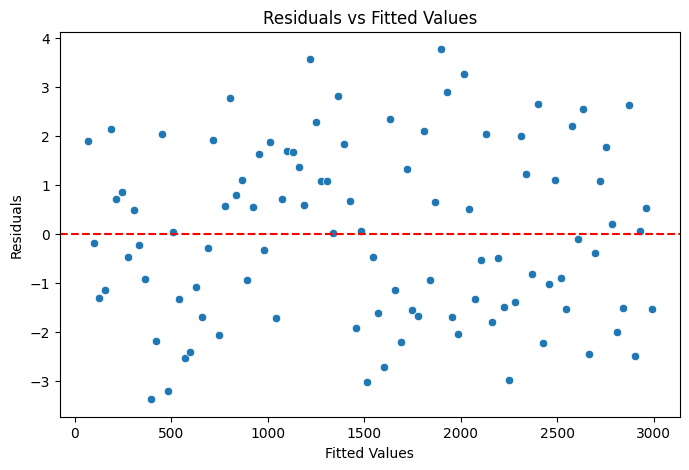

In [109]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

Berdasarkan analisis grafik residuals vs fitted values pada hasil di atas, sisaan model tersebar secara acak di sekitar garis nol dan tidak menunjukkan pola tertentu. penyebaran residual yang relatif merata menunjukkan bahwa asumsi linearitas dan homoskedastisitas terpenuhi. dilihat dari gambar tidak ditemukan adanya kecenderungan model dalam melakukan prediksi terlalu tinggi maupun terlalu rendah. dengan demikian, model regresi yang digunakan sudah cukup baik dalam menjelaskan hubungan antara waktu pengamatan dan nilai deret.

In [110]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.6148


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

Berdasarkan hasil uji Breusch-Pagan, diperoleh nilai p-value sebesar 0,6148 yang lebih besar dari taraf signifikansi 5%. hal ini menunjukkan bahwa tidak terdapat gejala heteroskedastisitas pada model regresi. sehingga asumsi regresi linear terkait kesamaan varians sisaan telah terpenuhi.

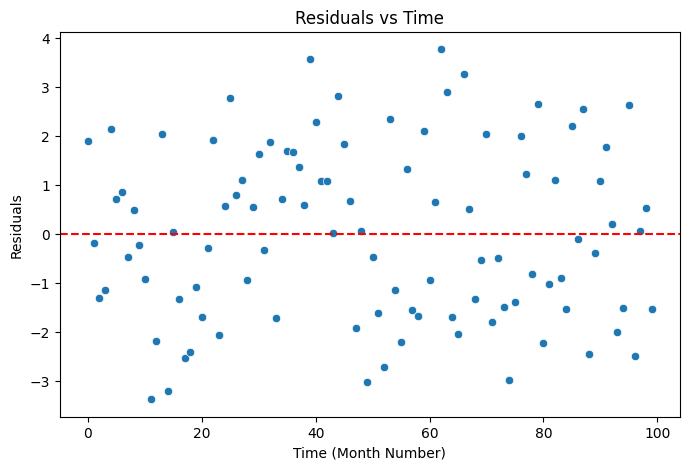

In [111]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


Berdasarkan grafik Residuals vs Time, residual model tersebar secara acak di sekitar nilai nol dan tidak menunjukkan pola tertentu sepanjang periode pengamatan. hal ini menunjukkan bahwa residual tidak memiliki hubungan dengan waktu atau autokorelasi yang kuat. selain itu, penyebaran residual yang relatif konstan menunjukkan bahwa varians residual stabil. oleh karena itu, model regresi telah memenuhi asumsi bahwa sisaan bersifat acak dan independen terhadap waktu.

<Figure size 800x500 with 0 Axes>

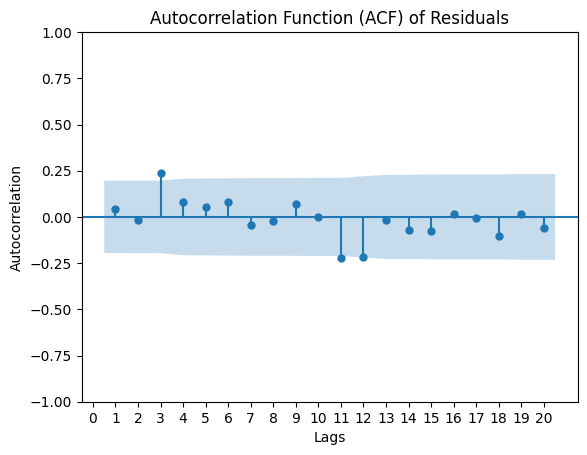

In [112]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

Berdasarkan grafik Autocorrelation Function (ACF) residual, sebagian besar nilai autokorelasi berada dalam batas interval kepercayaan 95%. Hal ini menunjukkan bahwa tidak terdapat autokorelasi yang signifikan pada residual. Dengan demikian, residual dapat dianggap bersifat acak dan independen terhadap waktu. Model regresi telah memenuhi asumsi independensi error sehingga model dapat dikatakan layak digunakan untuk menggambarkan pola kecenderungan linear pada data.

In [113]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.176517   0.674383
2    0.203749   0.903143
3    6.174589   0.103418
4    6.897843   0.141386
5    7.205689   0.205787
6    7.874193   0.247466
7    8.063450   0.327032
8    8.120949   0.421746
9    8.665086   0.468746
10   8.665102   0.564154
11  14.333509   0.215085
12  19.688185   0.073219
13  19.723379   0.102326
14  20.346340   0.119595
15  21.084390   0.134155
16  21.123723   0.173804
17  21.131281   0.220473
18  22.471566   0.211720
19  22.493570   0.260385


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

Berdasarkan hasil uji Ljung-Box, seluruh nilai p-value pada berbagai lag lebih besar dari tingkat signifikansi 5% (α = 0,05). Hal ini menunjukkan bahwa tidak terdapat autokorelasi yang signifikan pada residual model. Dengan demikian, residual dapat dianggap bersifat acak (white noise) dan independen terhadap waktu. Hasil ini menunjukkan bahwa model regresi telah memenuhi asumsi independensi error dan tidak terdapat pola ketergantungan antar pengamatan yang belum dijelaskan oleh model.

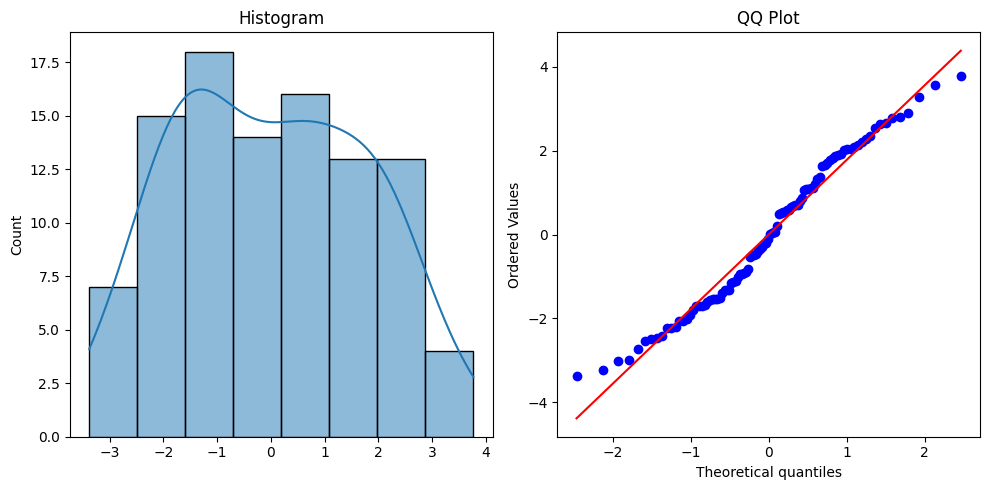

In [114]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

pada Histogram menunjukkan bahwa residual memiliki pola distribusi yang mendekati distribusi normal. Hal ini mengindikasikan bahwa kesalahan prediksi model tersebar secara wajar dan tidak memiliki penyimpangan besar dari asumsi normalitas. sedangkan, Q-Q Plot menunjukkan bahwa residual mengikuti pola distribusi normal karena sebagian besar titik berada dekat dengan garis referensi. Penyimpangan kecil pada bagian ekor menunjukkan adanya variasi kecil, namun tidak cukup kuat untuk menunjukkan pelanggaran normalitas.


In [115]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9729243532342543, p-value = 0.03716488510183192


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

Hasil uji Shapiro-Wilk menunjukkan nilai statistik sebesar 0,9729 dengan p-value 0,0372. Karena nilai p-value lebih kecil dari 0,05, maka residual dinyatakan tidak berdistribusi normal secara statistik. Namun, berdasarkan pemeriksaan visual melalui histogram dan Q-Q Plot, penyimpangan yang terjadi relatif kecil sehingga model masih dapat dianggap cukup baik, terutama karena jumlah pengamatan yang digunakan cukup besar (n = 100).

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [116]:
# Menentukan parameter simulasi
np.random.seed(1059)
n_periods = 120
beta_0, beta_1, beta_2= 109, 29.5, 1.18
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

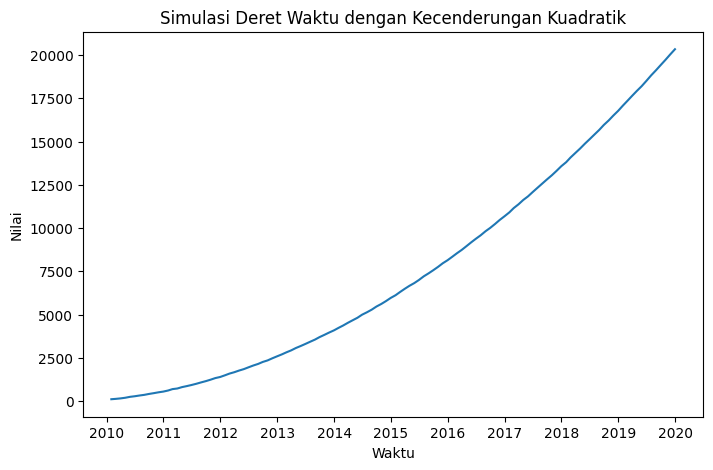

In [119]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

Deret dengan kecenderungan kuadratik menunjukkan pola peningkatan yang tidak konstan, di mana nilai deret meningkat semakin cepat seiring bertambahnya waktu. Berbeda dengan kecenderungan linear yang memiliki pola kenaikan konstan dan membentuk garis lurus, pola kuadratik membentuk kurva karena terdapat pengaruh kuadrat waktu. Hal ini menunjukkan bahwa perubahan antarperiode pada deret kuadratik semakin besar, sehingga model kuadratik lebih sesuai untuk menggambarkan data yang mengalami percepatan pertumbuhan.

In [120]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data

# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.733e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:08:50   Log-Likelihood:                -431.37
No. Observations:                 120   AIC:                             868.7
Df Residuals:                     117   BIC:                             877.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        105.6336      2.403     43.956      0.0

Hasil pengepasan model regresi kuadratik menghasilkan persamaan (Yt = 105,63 + 29,61X + 1,17 X^2). Model memiliki tingkat kecocokan yang sangat baik dengan nilai (R^2 = 1,000), yang menunjukkan bahwa hampir seluruh variasi data dapat dijelaskan oleh komponen waktu dan waktu kuadrat. Seluruh parameter model signifikan secara statistik, sehingga kecenderungan linear dan kuadratik terbukti berpengaruh terhadap perubahan nilai deret. Hasil estimasi parameter juga sangat mendekati nilai asli simulasi, sehingga model regresi kuadratik dinilai mampu menggambarkan pola pertumbuhan data dengan baik.

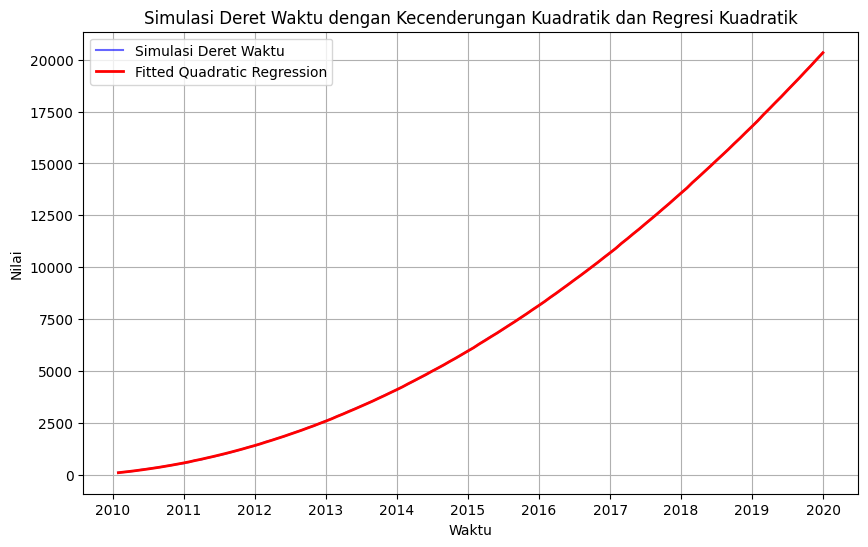

In [121]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

Berdasarkan hasil pemeriksaan asumsi model regresi kuadratik, residual menunjukkan distribusi yang mendekati normal berdasarkan uji Jarque-Bera dengan p-value 0,202 > 0,05. Nilai Durbin-Watson sebesar 1,961 yang mendekati 2 menunjukkan bahwa tidak terdapat autokorelasi yang berarti pada residual. Model juga memiliki nilai R-squared sebesar 1,000 sehingga mampu menjelaskan variasi data dengan sangat baik. Namun, asumsi homoskedastisitas perlu dikonfirmasi melalui uji Breusch-Pagan khusus pada model kuadratik, sedangkan nilai condition number yang tinggi menunjukkan adanya potensi masalah numerik akibat penggunaan variabel waktu dan kuadrat waktu.jadi, Secara umum model regresi kuadratik memiliki kecocokan yang sangat baik dan sebagian besar asumsi telah terpenuhi.

In [ ]:
# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [124]:
# Menentukan parameter simulasi
np.random.seed(1059)
n_periods = 120
beta0, beta1, beta2=109,1475,118
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


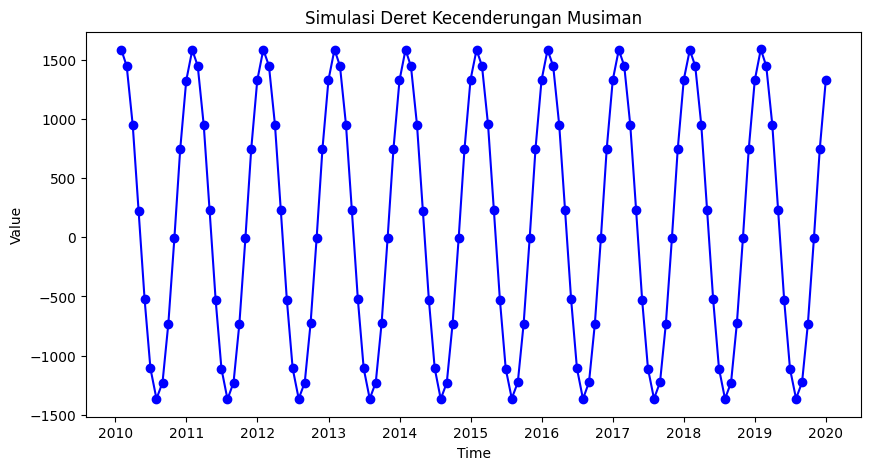

In [125]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Berdasarkan asumsi bahwa deret memiliki periode musiman 12, pola yang terlihat menunjukkan adanya fluktuasi yang berulang setiap satu tahun. Deret mengalami kenaikan dan penurunan secara periodik dengan pola yang relatif sama pada setiap siklus. Tidak terdapat kecenderungan tren jangka panjang, sehingga variasi utama dalam data berasal dari komponen musiman. Dengan demikian, deret tersebut dapat dikategorikan sebagai deret waktu musiman dengan periode 12 bulan yang memiliki pola berulang dan stabil.

In [126]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [87]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [127]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [128]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.547e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.13e-294
Time:                        13:19:33   Log-Likelihood:                -236.79
No. Observations:                 120   AIC:                             497.6
Df Residuals:                     108   BIC:                             531.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     1584.0255      0.580   2729.932      0.0

Bagaimana interpretasi dari hasil tersebut?

Hasil regresi musiman menunjukkan bahwa model mampu menjelaskan pola perubahan nilai deret dengan sangat baik, ditunjukkan oleh nilai (R^2 = 0,999). pada uji F menunjukkan bahwa variabel bulan secara bersama-sama berpengaruh signifikan terhadap nilai deret. Koefisien bulanan menunjukkan adanya pola musiman tahunan, dengan nilai tertinggi terjadi pada bulan Maret dan nilai terendah pada bulan September. selain itu, hasil pemeriksaan residual menunjukkan bahwa model memenuhi asumsi normalitas dan tidak mengalami masalah autokorelasi yang berarti. Dengan demikian, model regresi musiman yang digunakan sudah sangat baik dalam menggambarkan pola deret waktu dengan periode musiman 12 bulan.

In [129]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

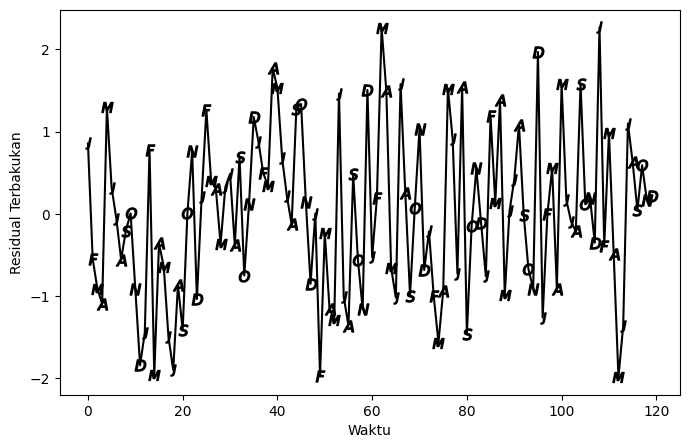

In [130]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


Berdasarkan grafik residual terbakukan terhadap waktu, residual terlihat menyebar secara acak di sekitar nilai nol tanpa membentuk pola tertentu. Penyebaran residual yang relatif stabil menunjukkan bahwa tidak terdapat masalah heteroskedastisitas, sedangkan tidak adanya pola berulang terhadap waktu menunjukkan bahwa residual tidak mengalami autokorelasi yang signifikan. Dengan demikian, model regresi musiman telah mampu menangkap pola utama dalam data dan residual yang dihasilkan dapat dianggap bersifat acak serta memenuhi asumsi dasar model.

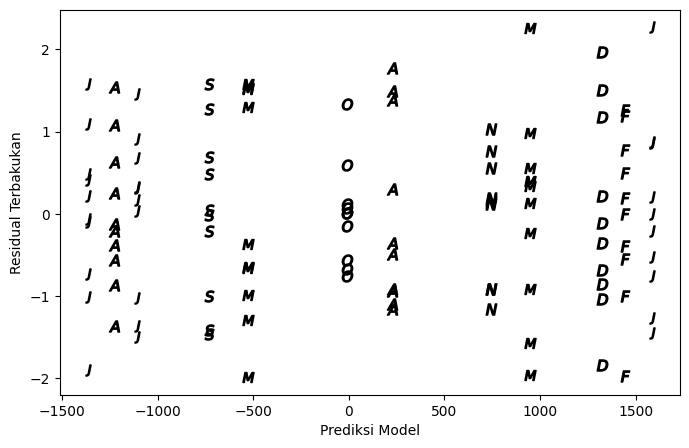

In [131]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

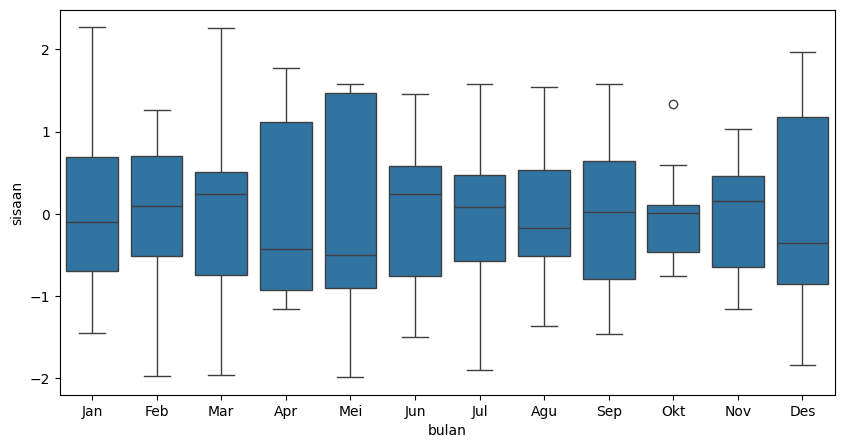

In [132]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?

Berdasarkan tiga plot diagnostik residual, yaitu residual terbakukan terhadap waktu, ACF residual, dan boxplot residual berdasarkan bulan, dapat disimpulkan bahwa model regresi musiman telah memenuhi asumsi dasar model. Residual tersebar secara acak di sekitar nol tanpa menunjukkan pola waktu maupun pola musiman yang tersisa. Plot ACF menunjukkan tidak adanya autokorelasi yang signifikan, sedangkan boxplot residual per bulan menunjukkan penyebaran residual yang relatif stabil antarperiode. Dengan demikian, model telah berhasil menangkap pola musiman dalam data dan residual yang dihasilkan dapat dianggap sebagai noise acak.

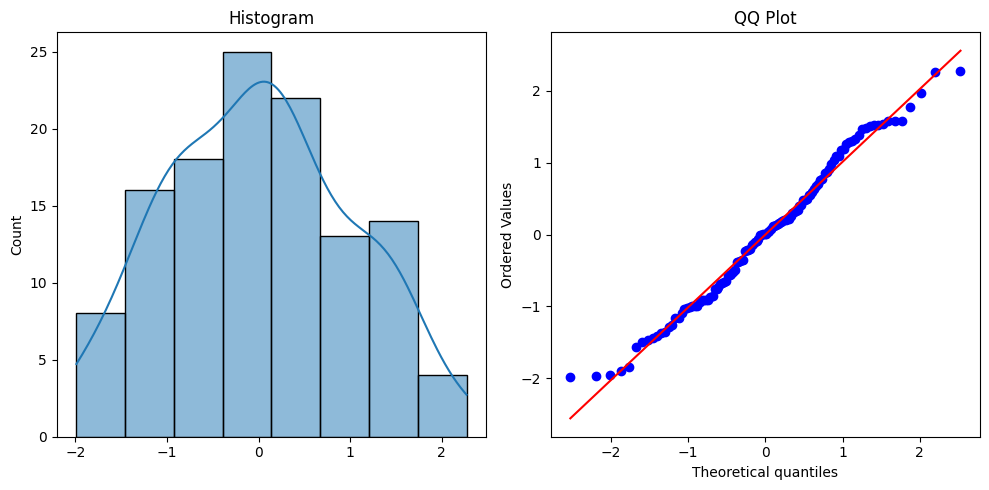

In [133]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

Berdasarkan pemeriksaan grafik histogram dan Normal Q-Q Plot, residual model regresi musiman menunjukkan pola yang mendekati distribusi normal. Sebagian besar titik pada Q-Q Plot mengikuti garis diagonal dan histogram menunjukkan distribusi yang relatif simetris. Hal ini mengindikasikan bahwa model telah memenuhi asumsi normalitas residual.

In [37]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [134]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [135]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.547e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.13e-294
Time:                        13:20:25   Log-Likelihood:                -236.79
No. Observations:                 120   AIC:                             497.6
Df Residuals:                     108   BIC:                             531.0
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1584.0255      0.580   2729.932      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

Model regresi musiman dengan intersep menghasilkan nilai (R^2=1,000), yang menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi data berdasarkan pengaruh bulan. Intersep sebesar 1584,02 menunjukkan nilai rata-rata pada bulan Januari sebagai kategori dasar, sedangkan koefisien bulan lainnya menunjukkan perbedaan nilai masing-masing bulan terhadap Januari. Pola koefisien menunjukkan adanya variasi musiman yang kuat, dengan nilai tertinggi terjadi pada bulan Maret dan nilai terendah pada bulan September. Dibandingkan model tanpa intersep, model dengan intersep memberikan interpretasi yang lebih jelas karena terdapat kategori referensi sebagai pembanding. Berdasarkan uji normalitas dan Durbin-Watson, model telah memenuhi sebagian besar asumsi regresi. Dengan demikian, model regresi musiman dengan intersep dapat dikatakan sudah baik untuk menggambarkan pola musiman data.

In [ ]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [136]:
# Parameter
np.random.seed(1059)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 29.5, 590 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


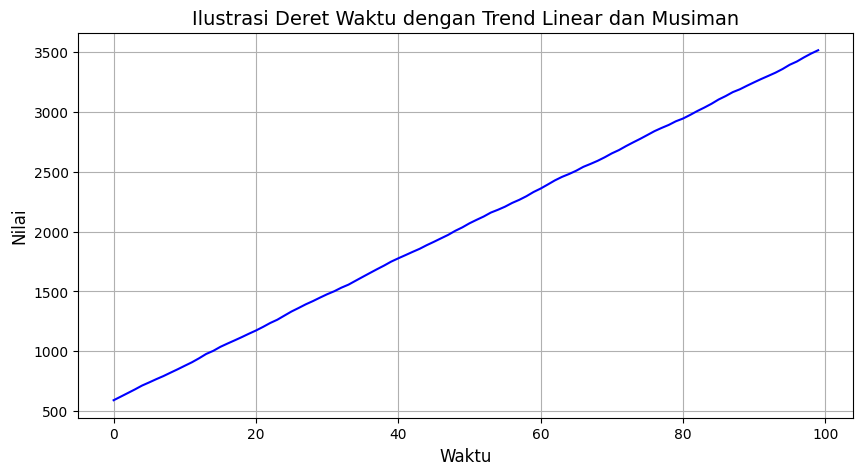

In [137]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

Grafik menunjukkan adanya kecenderungan meningkat secara linear dari waktu ke waktu. Hal ini terlihat dari pola data yang bergerak naik secara konsisten, yaitu nilai awal berada sekitar 590 dan meningkat hingga mencapai sekitar 3500 pada akhir periode. Peningkatan tersebut terjadi karena adanya komponen tren linear dengan parameter intersep (a) = 590 dan kemiringan/slope (b) = 29,5, yang berarti setiap kenaikan 1 periode waktu akan meningkatkan nilai deret sekitar 29,5 satuan. Secara keseluruhan, deret waktu tersebut memiliki tren linear positif yang dominan dengan pola musiman yang stabil. Artinya, nilai data cenderung terus meningkat dalam jangka panjang, tetapi tetap mengalami variasi berulang setiap 12 periode akibat pengaruh musiman. Model yang sesuai untuk menggambarkan data seperti ini adalah model deret waktu yang menggabungkan komponen tren dan musiman, seperti regresi tren dengan variabel musiman atau metode Holt-Winters dengan tren dan musiman.

In [139]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [140]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [100]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.248e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.83e-255
Time:                        12:38:24   Log-Likelihood:                -196.00
No. Observations:                 100   AIC:                             418.0
Df Residuals:                      87   BIC:                             451.9
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       68.2318      0.686     99.409      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

Hasil regresi dengan kombinasi tren linear dan variabel musiman menunjukkan bahwa model mampu menjelaskan variasi data dengan sangat baik, ditunjukkan oleh nilai (R^2=1,000). Koefisien periode sebesar 59,5074 menunjukkan adanya tren positif yang kuat, yaitu nilai deret meningkat sekitar 59,5 satuan setiap periode. Variabel musiman menunjukkan adanya perbedaan pola antarbulan, dengan pengaruh musiman terbesar terjadi pada bulan April dan terendah pada bulan Oktober. Seluruh parameter model signifikan secara statistik. Berdasarkan pemeriksaan residual, model memenuhi asumsi normalitas dan tidak menunjukkan adanya autokorelasi yang kuat. Dengan demikian, model regresi tren linear dengan komponen musiman telah mampu menggambarkan pola deret waktu dengan sangat baik.

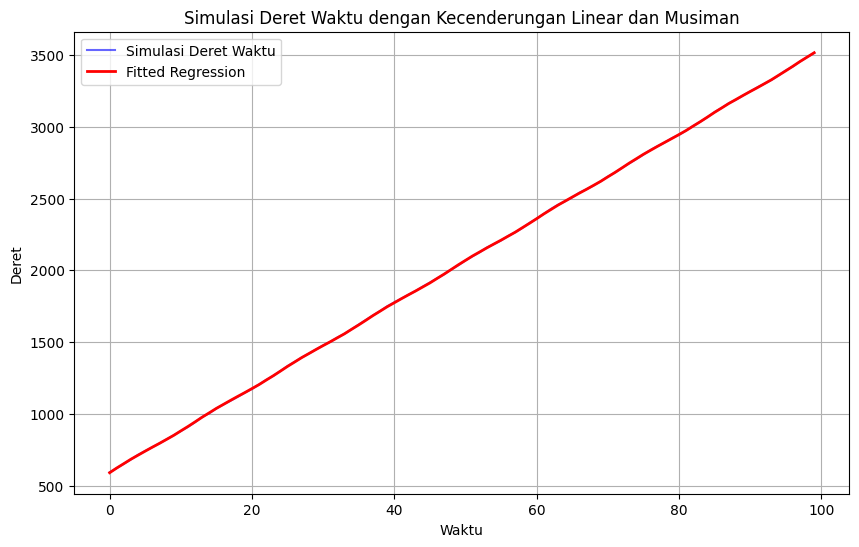

In [141]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

Berdasarkan pemeriksaan visual terhadap grafik, model regresi dengan komponen tren linear dan musiman telah memenuhi asumsi regresi. Tidak terlihat adanya pelanggaran asumsi linearitas, normalitas residual, homoskedastisitas, autokorelasi, maupun multikolinearitas. Garis regresi mampu mengikuti pola data dengan baik sehingga model dapat digunakan untuk menggambarkan hubungan antara waktu dan nilai deret.

In [46]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [142]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

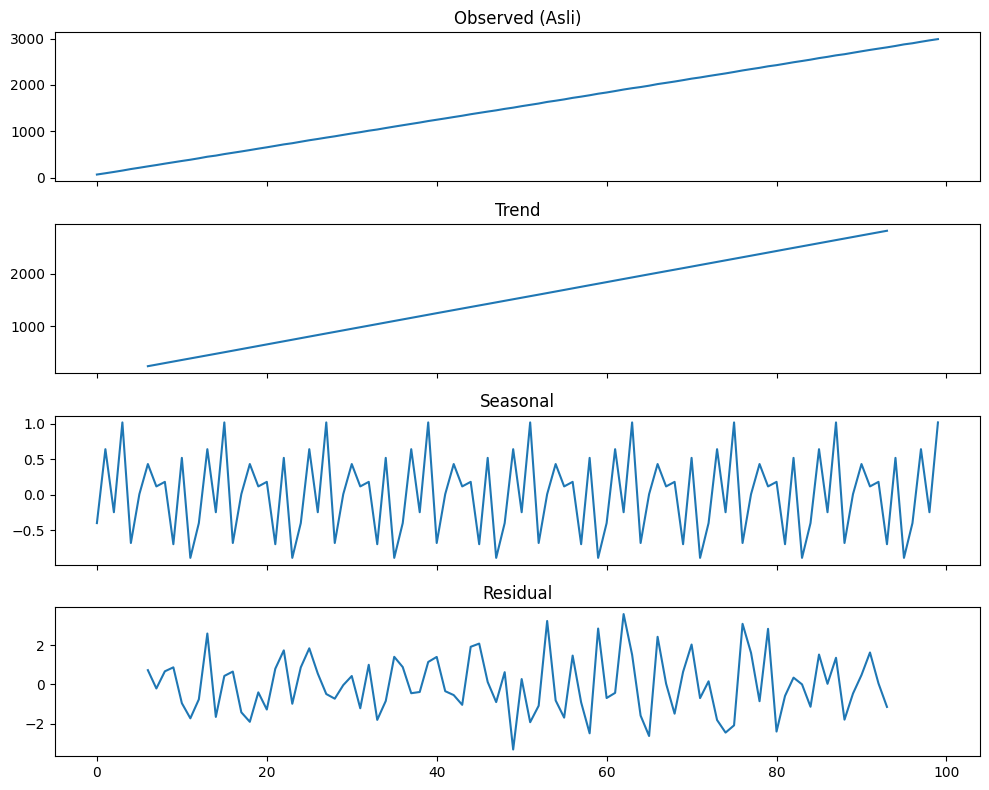

In [143]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi deret waktu, grafik Observed (Asli) menunjukkan bahwa data memiliki kecenderungan meningkat secara linear dari waktu ke waktu yang menunjukkan adanya tren positif yang dominan. Komponen Trend memperlihatkan pola kenaikan yang stabil, sehingga sebagian besar perubahan data dipengaruhi oleh faktor tren jangka panjang. Komponen Seasonal menunjukkan adanya pola fluktuasi berulang secara periodik di sekitar nilai nol, yang menandakan adanya pengaruh musiman tetapi dengan besaran yang relatif kecil dibandingkan tren. Sementara itu, komponen Residual berfluktuasi secara acak di sekitar nilai nol tanpa membentuk pola tertentu, sehingga menunjukkan bahwa sisa variasi data setelah memperhitungkan tren dan musiman bersifat acak. Secara keseluruhan, deret waktu tersebut didominasi oleh tren linear meningkat dengan komponen musiman yang stabil dan gangguan acak yang relatif kecil, sehingga model dekomposisi mampu menggambarkan pola utama dari data dengan baik.

In [43]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

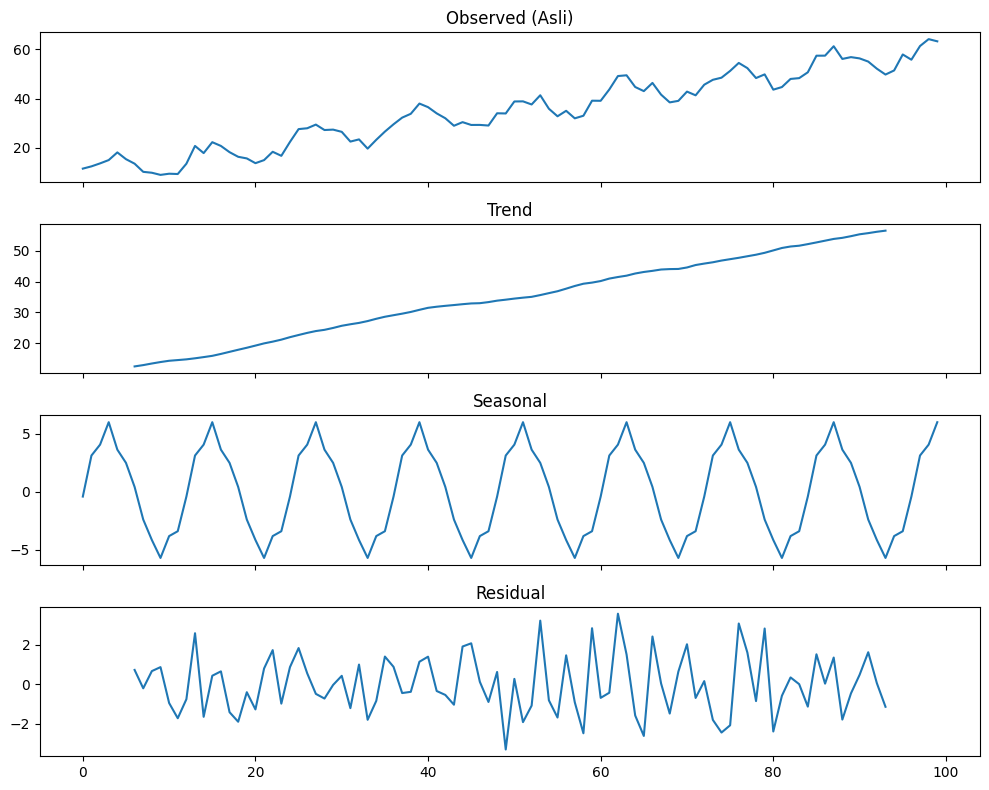

In [144]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi deret waktu pada grafik Observed (Asli), Trend, Seasonal, dan Residual, dapat diinterpretasikan bahwa data memiliki pola tren meningkat (trend positif) yang cukup kuat disertai pola musiman yang berulang secara teratur. Grafik Observed menunjukkan bahwa nilai data mengalami kenaikan dari awal periode hingga akhir periode, meskipun terdapat fluktuasi naik turun dalam jangka pendek. Komponen Trend memperlihatkan pola peningkatan yang stabil dari waktu ke waktu, yang menunjukkan adanya kecenderungan pertumbuhan jangka panjang pada data. Komponen Seasonal menunjukkan pola gelombang yang berulang secara konsisten dengan amplitudo sekitar ±5, sehingga menunjukkan adanya pengaruh musiman yang stabil pada periode tertentu.Secara keseluruhan, deret waktu ini dapat dikatakan memiliki tren positif dengan pola musiman yang jelas dan stabil, sedangkan pengaruh residual relatif kecil sehingga model dekomposisi mampu menggambarkan pola utama data dengan baik.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [145]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1059)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 2.95, 590 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

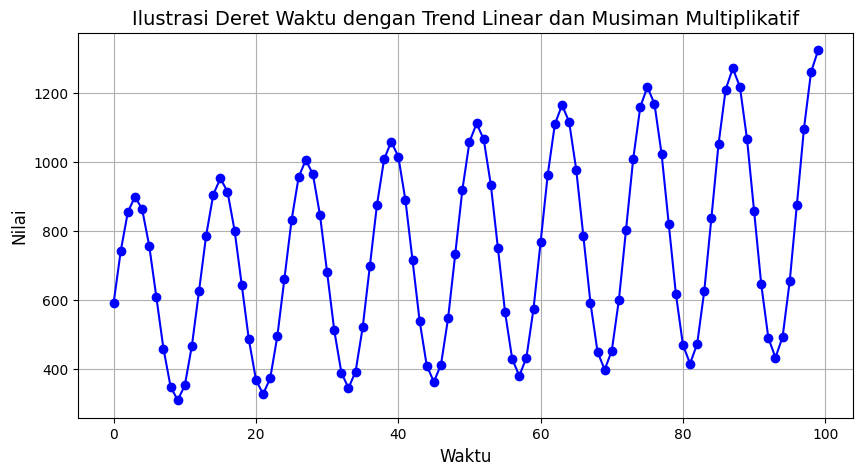

In [146]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Berdasarkan grafik "Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif", terlihat bahwa data memiliki kecenderungan meningkat secara linear dari waktu ke waktu disertai pola musiman yang berulang setiap 12 periode. Nilai data mengalami peningkatan dari sekitar 600 pada awal periode hingga lebih dari 1200 pada akhir periode, yang menunjukkan adanya tren positif yang dominan. Selain itu, terdapat pola naik turun yang terjadi secara periodik, di mana besar fluktuasi musiman semakin meningkat seiring meningkatnya nilai tren. Hal ini menunjukkan bahwa komponen musiman bersifat multiplikatif, yaitu pengaruh musiman bergantung pada tingkat nilai data; semakin besar tren, semakin besar pula variasi musimannya. Secara keseluruhan, deret waktu tersebut menggambarkan data dengan tren pertumbuhan positif dan pola musiman yang stabil namun memiliki amplitudo yang meningkat, sehingga model yang sesuai adalah model deret waktu dengan komponen tren dan musiman multiplikatif.

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [62]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

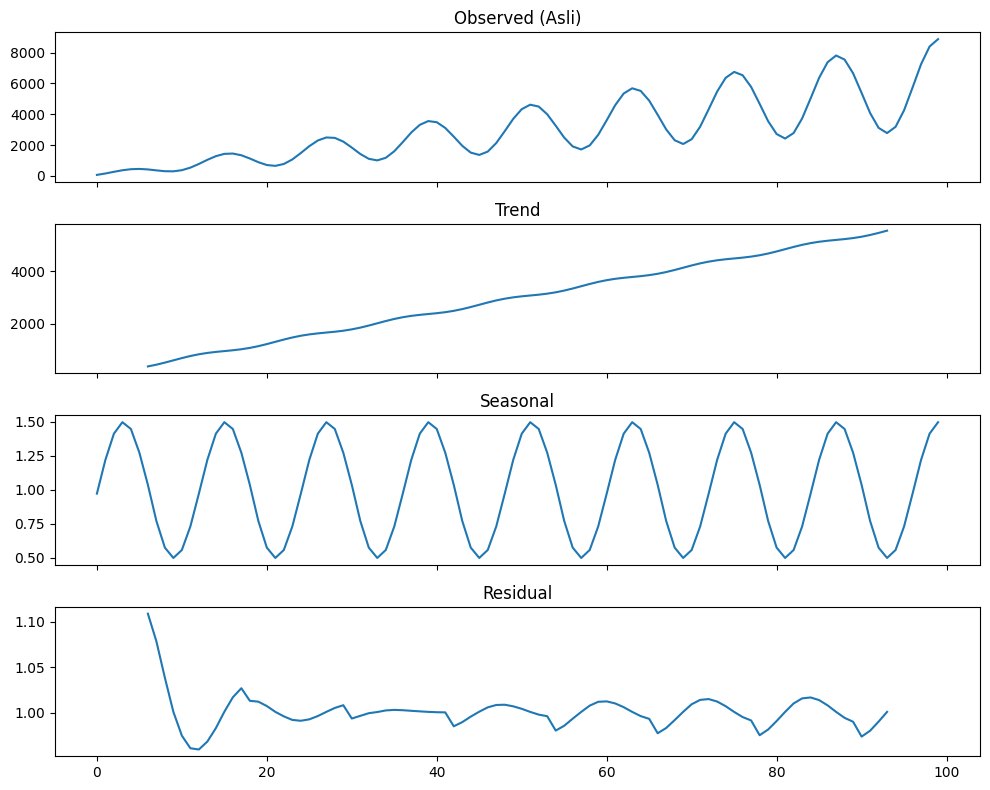

In [147]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

Berdasarkan hasil dekomposisi deret waktu pada grafik Observed (Asli), Trend, Seasonal, dan Residual, dapat diinterpretasikan bahwa data memiliki pola tren meningkat dengan komponen musiman multiplikatif yang kuat. Grafik Observed (Asli) menunjukkan bahwa nilai data mengalami peningkatan dari waktu ke waktu, dengan fluktuasi naik dan turun yang semakin besar pada periode akhir. Hal ini menunjukkan bahwa perubahan data dipengaruhi oleh tren pertumbuhan jangka panjang sekaligus variasi musiman yang mengikuti peningkatan nilai data. Komponen Trend memperlihatkan pola kenaikan yang stabil, yang menunjukkan adanya kecenderungan positif pada data. Komponen Seasonal menunjukkan pola berulang secara periodik dengan nilai berkisar antara sekitar 0,5 hingga 1,5, yang menunjukkan bahwa faktor musiman bekerja secara proporsional terhadap tingkat data (multiplikatif), bukan dengan penambahan nilai tetap. Sementara itu, komponen Residual berfluktuasi di sekitar nilai 1 dan tidak menunjukkan pola tertentu, yang berarti sisa variasi setelah memperhitungkan tren dan musiman bersifat acak. Secara keseluruhan, deret waktu tersebut didominasi oleh tren positif dan pola musiman multiplikatif yang stabil, di mana amplitudo variasi musiman semakin besar seiring meningkatnya nilai tren, sehingga model dekomposisi multiplikatif sesuai untuk menggambarkan karakteristik data tersebut.

In [148]:
# Parameter
np.random.seed(1059)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

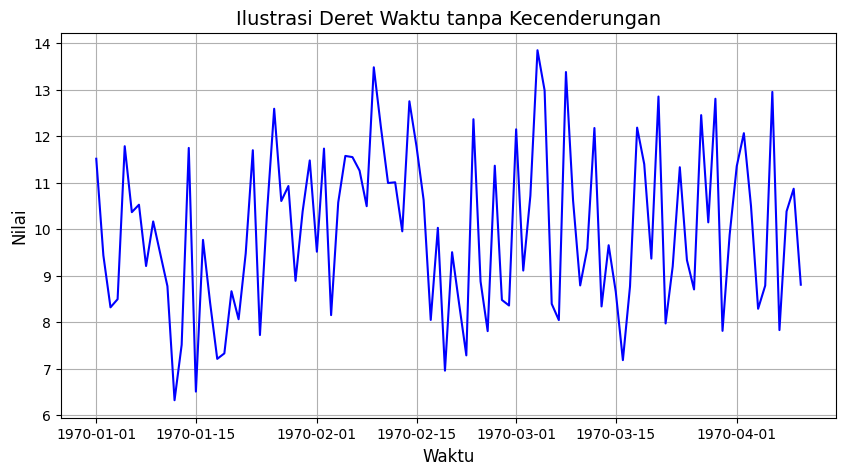

In [150]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

Berdasarkan grafik ilustrasi deret waktu tanpa kecenderungan, terlihat bahwa data hanya mengalami fluktuasi acak di sekitar nilai rata-rata 10. Tidak ditemukan adanya pola peningkatan atau penurunan jangka panjang maupun pola musiman yang berulang. Dengan demikian, deret tersebut hanya terdiri dari komponen noise atau variasi acak, sehingga perubahan nilai dari waktu ke waktu tidak dapat dijelaskan oleh tren maupun pola musiman.

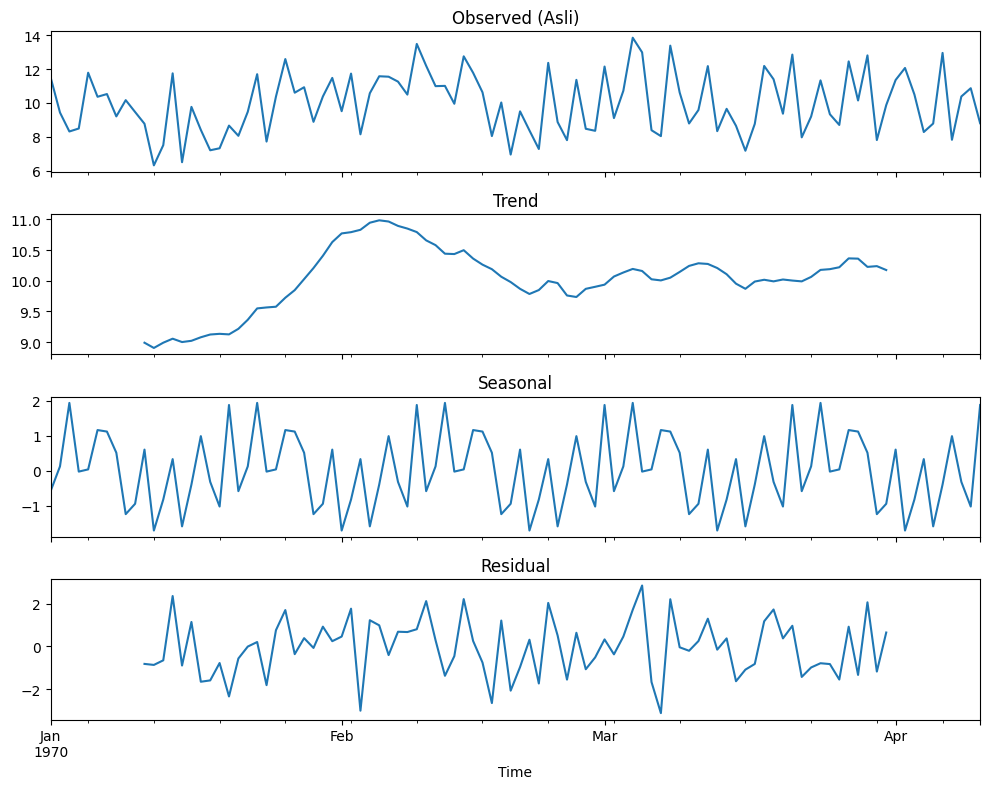

In [151]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

Berdasarkan hasil dekomposisi deret waktu, data asli menunjukkan fluktuasi yang relatif stabil tanpa adanya kecenderungan meningkat atau menurun secara jelas. Komponen tren berada di sekitar nilai konstan sehingga tidak menunjukkan adanya tren jangka panjang yang signifikan. Komponen musiman juga tidak memperlihatkan pola berulang yang kuat. Sebagian besar variasi data berasal dari komponen residual atau noise acak. Dengan demikian, deret waktu tersebut dapat dikategorikan sebagai deret tanpa tren dan tanpa pola musiman yang dominan, sehingga perubahan nilai terutama dipengaruhi oleh faktor acak.